# **Fashion Attribute Extraction Using FashionCLIP and Vision Transformers**

## **Project Overview**

Fashion e-commerce platforms contain thousands of clothing images. Manually tagging attributes such as clothing type, color, fit, and style is time-consuming and expensive.

This project utilizes the FashionCLIP model, a Vision Transformer-based deep learning architecture, to automatically extract fashion attributes from uploaded clothing images. The model analyzes the image and predicts multiple characteristics including garment category, color, fit type, and style-related information.

The system helps automate fashion catalog management, product tagging, inventory organization, and recommendation systems.

In [ ]:
! pip install datasets

In [ ]:
from datasets import load_dataset
from PIL import Image

In [ ]:
!pip install huggingface_hub

In [ ]:
from huggingface_hub import login
login(token="hf_token")

## **Dataset Loading**

# Hugging FAce Data Link : https://huggingface.co/datasets/innople/fashion_design

In [ ]:
# Fashion Design Dataset from Hugging Face
ds = load_dataset("innople/fashion_design", split="train", streaming=True)

Resolving data files:   0%|          | 0/35764 [00:00<?, ?it/s]

In [ ]:
# info = load_dataset("innople/fashion_design")
# print(info)

In [ ]:
iters = iter(ds)

## **Data Visualization**

In [ ]:
import matplotlib.pyplot as plt

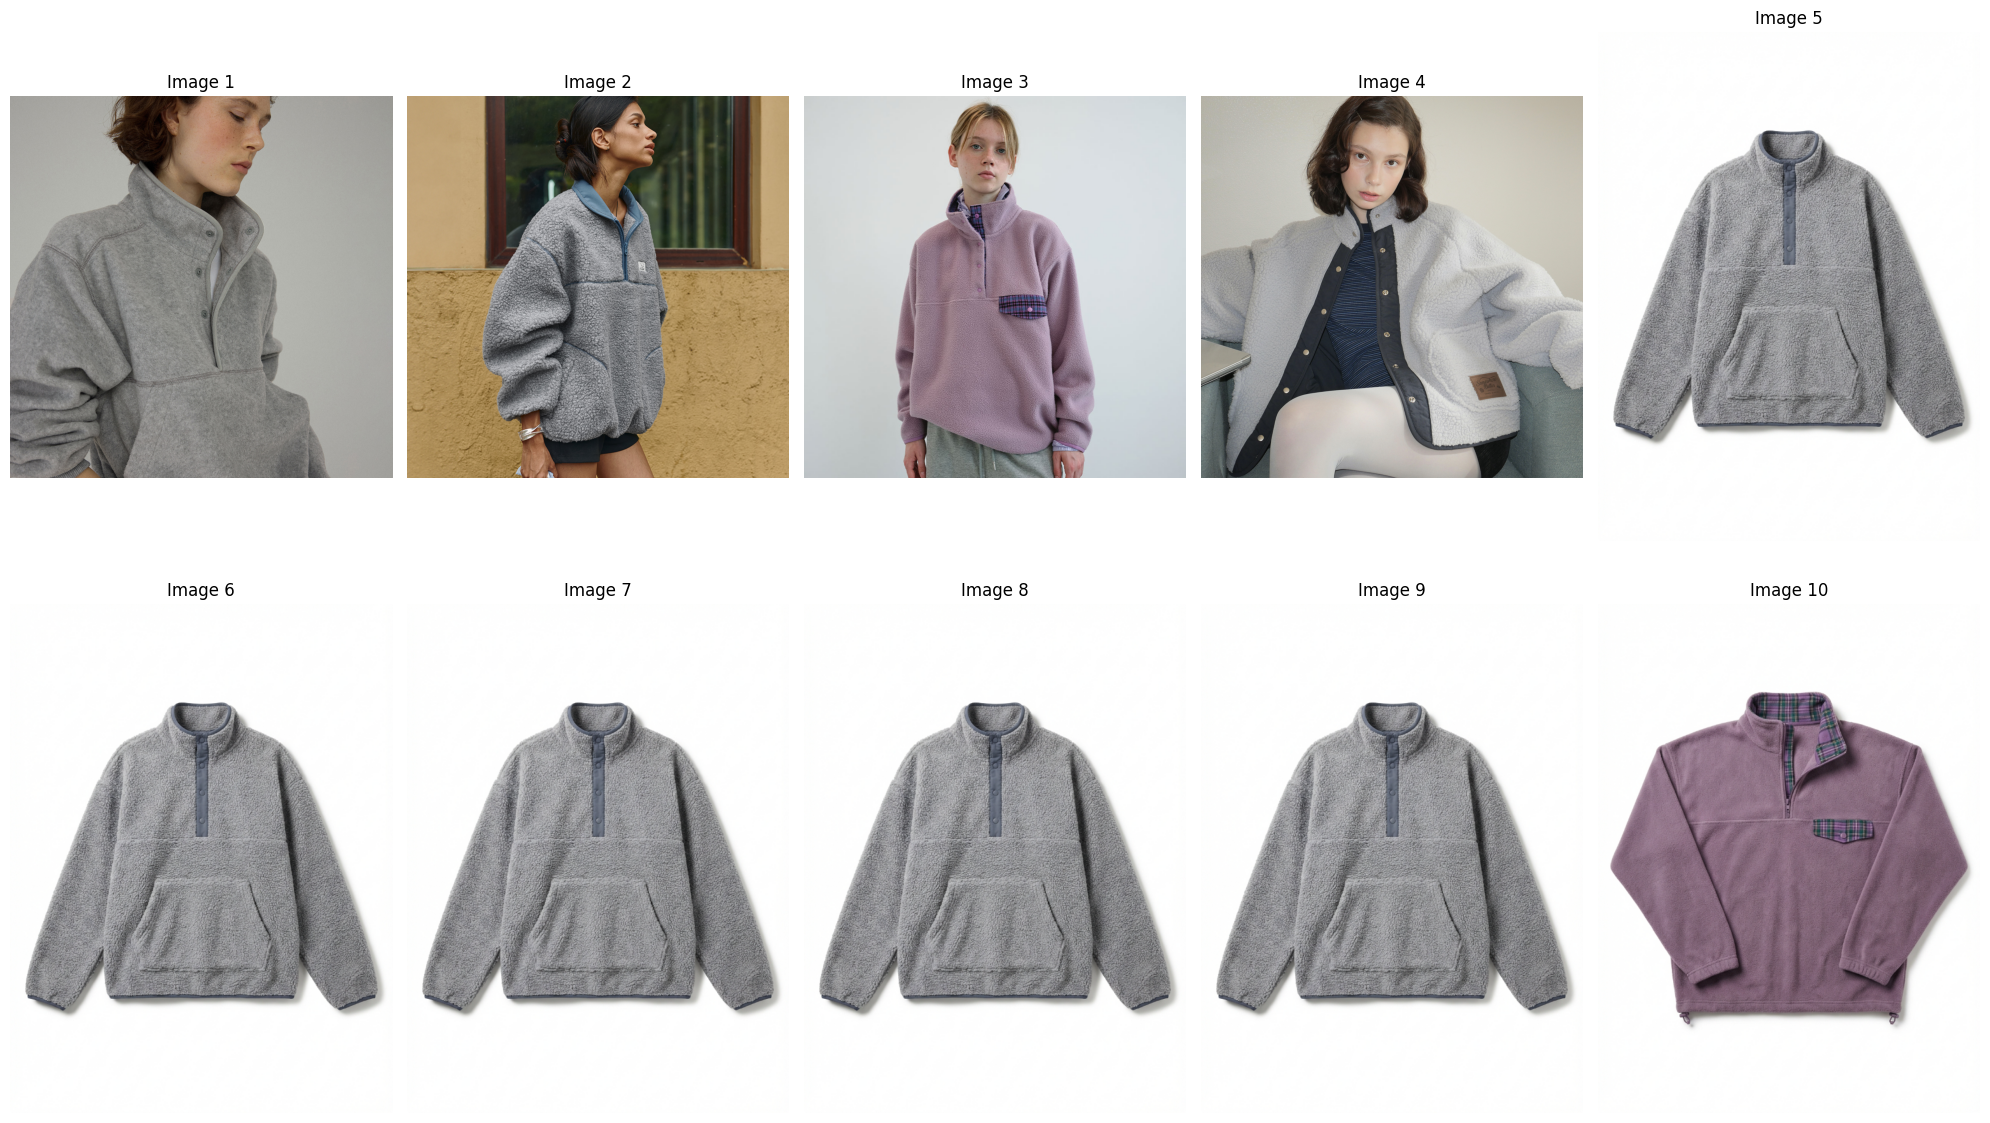

In [ ]:
fig, axes = plt.subplots(2,5, figsize=(20,12))
axes = axes.flatten()

for i in range(10):
    sample = next(iters)
    image = sample['image']
    axes[i].imshow(image)
    axes[i].axis('off')
    axes[i].set_title(f"Image {i+1}")

plt.tight_layout()
plt.show()

## **Loading FashionCLIP Model**

# The model uses a ViT-B/32 Transformer architecture as an image encoder and uses a masked self-attention Transformer as a text encoder. These encoders are trained to maximize the similarity of (image, text) pairs via a contrastive loss.

# The original implementation had two variants: one using a ResNet image encoder and the other using a Vision Transformer. This repository has the variant with the Vision Transformer.

# Model Link : https://huggingface.co/patrickjohncyh/fashion-clip

In [ ]:
!pip install transformers torch pillow

In [ ]:
from transformers import CLIPProcessor, CLIPModel
import torch

In [ ]:
# Using FashionClip Model From Hugging Face

In [ ]:
model_name = "patrickjohncyh/fashion-clip"

In [ ]:
model = CLIPModel.from_pretrained(model_name)
processor = CLIPProcessor.from_pretrained(model_name)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/568 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

## **Fashion Labels Definition**

In [ ]:
fashion_labels = {
    "cloth_type": [
        "t-shirt", "shirt", "kurta", "jacket",
        "jeans", "trousers", "saree", "lehenga",
        "hoodie", "sweater", "blazer", "shorts",
        "skirt", "dress", "top", "coat"
    ],

    "fit_type": [
        "slim fit", "regular fit",
        "oversized fit", "loose fit", "relaxed fit"
    ],

    "color": [
        "white", "black", "red", "blue",
        "green", "yellow", "pink", "grey",
        "navy blue", "beige", "brown", "orange"
    ],

    "pattern": [
        "solid plain", "striped", "checked",
        "printed", "floral", "geometric",
        "camouflage", "abstract"
    ],

    "sleeve": [
        "full sleeve", "half sleeve",
        "sleeveless", "three quarter sleeve"
    ],

    "neck_type": [
        "round neck", "v-neck", "collar neck",
        "polo neck", "hooded", "mandarin collar"
    ],

    "occasion": [
        "casual wear", "formal wear",
        "party wear", "ethnic wear",
        "sportswear", "workwear"
    ],

    "fabric_look": [
        "cotton fabric", "denim fabric",
        "silk fabric", "woolen fabric",
        "linen fabric", "synthetic fabric"
    ]
}

## **Feature Extraction & Prediction**

In [ ]:
from google.colab import files

Saving test5.jpg to test5.jpg

 Analysis Results for: test5.jpg


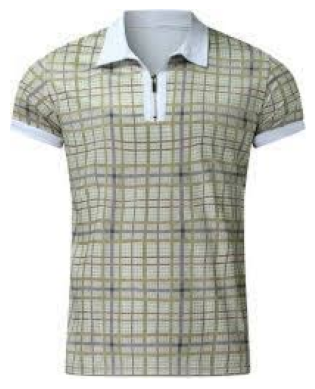

✅ SHIRT (47.2%)
✅ CHECKED (18.5%)
✅ CHECKED (18.5%)


In [ ]:
import torch
import numpy as np
from PIL import Image
from google.colab import files
import matplotlib.pyplot as plt

def extract_fashion_features(labels_dict):
    # Flatten labels for CLIP processing
    all_labels = []
    for category in labels_dict.values():
        all_labels.extend(category)

    print("--- Image Upload Karein ---")
    uploaded = files.upload()

    for file_name in uploaded.keys():
        image = Image.open(file_name).convert('RGB')

        # Inference
        inputs = processor(text=all_labels, images=image, return_tensors="pt", padding=True)
        with torch.no_grad():
            outputs = model(**inputs)
            probs = outputs.logits_per_image.softmax(dim=1)[0]

        # Results Mapping
        print(f"\n--- Analysis Results for: {file_name} ---")
        plt.imshow(image)
        plt.axis('off')
        plt.show()

        # Har category se best label chunein
        print("Detected Features:")
        for category, options in labels_dict.items():
            # Is category ke labels ke scores nikalein
            category_indices = [all_labels.index(opt) for opt in options]
            category_probs = probs[category_indices]

            # Sabse high confidence wala label pick karein
            best_idx = torch.argmax(category_probs)
            if category_probs[best_idx] > 0.05: # Threshold
                print(f"✅ {category.replace('_', ' ').upper()}: {options[best_idx]}")

# Run function
extract_fashion_features(fashion_labels)

 **This project uses the FashionCLIP pretrained Vision Transformer model to automatically extract fashion attributes from clothing images. The model compares image features with predefined fashion labels and predicts attributes such as cloth type, fit type, and color. The system can automate product tagging in fashion e-commerce platforms, improving efficiency and reducing manual work.**